## Fetch and Display NYSE Stock Data

### yfinance module
nyse 종목

In [1]:
# _tsa_00.py
# nyse stock

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [2]:
# import pandas as pd
# import yfinance as yf

# 종목 리스트 한 번에 가져오는 아이디어.
# 1. 나스닥 주요 상위 종목 티커 리스트
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META",
           "GOOGL", "TSLA", "AVGO", "COST", "NFLX",
           "SKHY", "MU", "AMD", "ASML", "TSM",
           "INTC"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for tckr in tickers:
    stock = yf.Ticker(tckr)
    info = stock.info

    stock_data.append({
        "티커": tckr,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

# 티커에 대한 가격, 볼륨 데이터, k 년 자료 가져오기
df_dat = yf.download(tickers, period='1y', auto_adjust=True)
df_dat.info()   # ticker마다 close, open, volume 등

# 다운 자료 중 종가 추출
df_dat_cls = df_dat['Close'].copy()
df_dat_cls

       티커                                                기업명  \
0    AAPL                                         Apple Inc.   
1    MSFT                              Microsoft Corporation   
2    NVDA                                 NVIDIA Corporation   
3    AMZN                                   Amazon.com, Inc.   
4    META                               Meta Platforms, Inc.   
5   GOOGL                                      Alphabet Inc.   
6    TSLA                                        Tesla, Inc.   
7    AVGO                                      Broadcom Inc.   
8    COST                       Costco Wholesale Corporation   
9    NFLX                                      Netflix, Inc.   
10   SKHY                                      SK hynix Inc.   
11     MU                            Micron Technology, Inc.   
12    AMD                       Advanced Micro Devices, Inc.   
13   ASML                                  ASML Holding N.V.   
14    TSM  Taiwan Semiconductor Manufact

[*********************100%***********************]  16 of 16 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-12 to 2026-09-11
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMD)     251 non-null    float64
 2   (Close, AMZN)    251 non-null    float64
 3   (Close, ASML)    251 non-null    float64
 4   (Close, AVGO)    251 non-null    float64
 5   (Close, COST)    251 non-null    float64
 6   (Close, GOOGL)   251 non-null    float64
 7   (Close, INTC)    251 non-null    float64
 8   (Close, META)    251 non-null    float64
 9   (Close, MSFT)    251 non-null    float64
 10  (Close, MU)      251 non-null    float64
 11  (Close, NFLX)    251 non-null    float64
 12  (Close, NVDA)    251 non-null    float64
 13  (Close, SKHY)    45 non-null     float64
 14  (Close, TSLA)    251 non-null    float64
 15  (Close, TSM)     251 non-null    float64
 16  (High, AAPL)     251 non-null    float64
 1

Ticker,AAPL,AMD,AMZN,ASML,AVGO,COST,GOOGL,INTC,META,MSFT,MU,NFLX,NVDA,SKHY,TSLA,TSM
Date,,,,,,,,,,,,,,,,
2025-09-12,233.208542,158.570007,228.149994,808.544434,357.252350,962.285522,240.175385,24.080000,753.121704,505.738953,156.978027,118.844002,177.395004,NaN,395.940002,256.493317
2025-09-15,235.828857,161.160004,231.429993,861.624817,361.441681,954.530701,250.957336,24.770000,762.201843,511.154358,157.517197,120.225998,177.325165,NaN,410.040009,258.520905
2025-09-16,237.273514,160.460007,234.050003,872.671997,357.381409,946.547302,250.508514,25.270000,776.455139,504.885956,158.565506,120.051003,174.462021,NaN,421.619995,260.011139
2025-09-17,238.110443,159.160004,231.619995,866.562317,343.652039,957.443787,248.882736,24.900000,773.185852,505.857941,159.733643,122.849998,169.882980,NaN,425.859985,260.735474
2025-09-18,237.004517,157.919998,231.229996,921.728882,342.838013,946.835632,251.376266,30.570000,777.701111,504.300812,168.619370,120.778000,175.818787,NaN,416.850006,266.539734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,319.970001,477.570007,258.510010,1714.880005,357.899994,915.739990,338.459991,95.800003,616.770020,499.700012,1016.590027,78.250000,230.102524,177.000000,354.079987,428.910004
2026-09-08,316.220001,505.739990,256.970001,1764.849976,368.559998,910.179993,338.359985,104.470001,613.479980,493.950012,1000.260010,76.769997,225.477692,185.550003,368.160004,439.000000
2026-09-09,315.339996,521.099976,252.399994,1729.520020,364.380005,902.599976,330.649994,106.239998,653.690002,491.649994,1027.770020,76.029999,223.419998,198.630005,367.809998,435.359985


### subplots, line chart, price changes

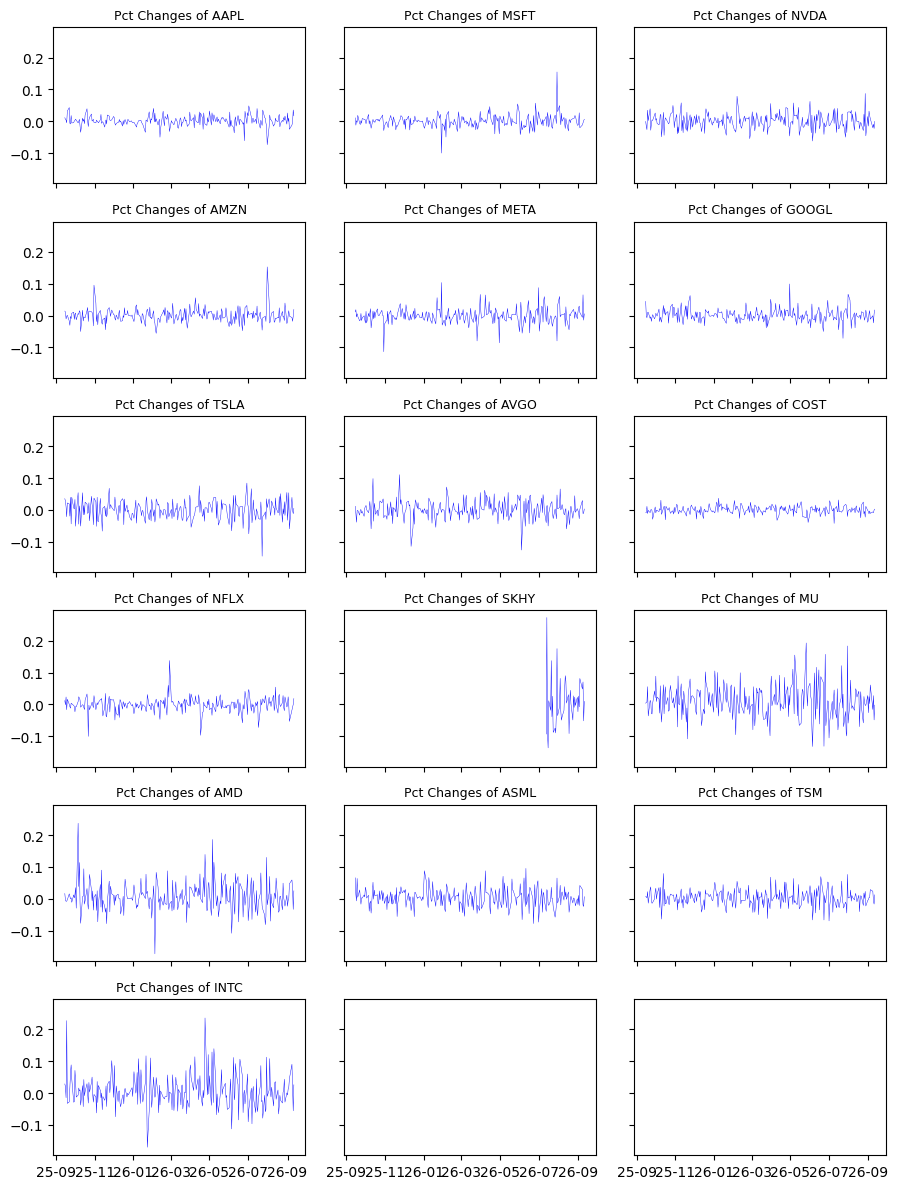

In [11]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*3, sub_r*2),
                         sharex=True,
                         sharey=True
                         )

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd,
          df_dat_cls[ticker].pct_change(fill_method=None),
          color='blue',
          linewidth=0.3
          )  # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
  ax.set_title(f" Pct Changes of {ticker} ", fontsize=9)
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### subplots, histograms, pct changes

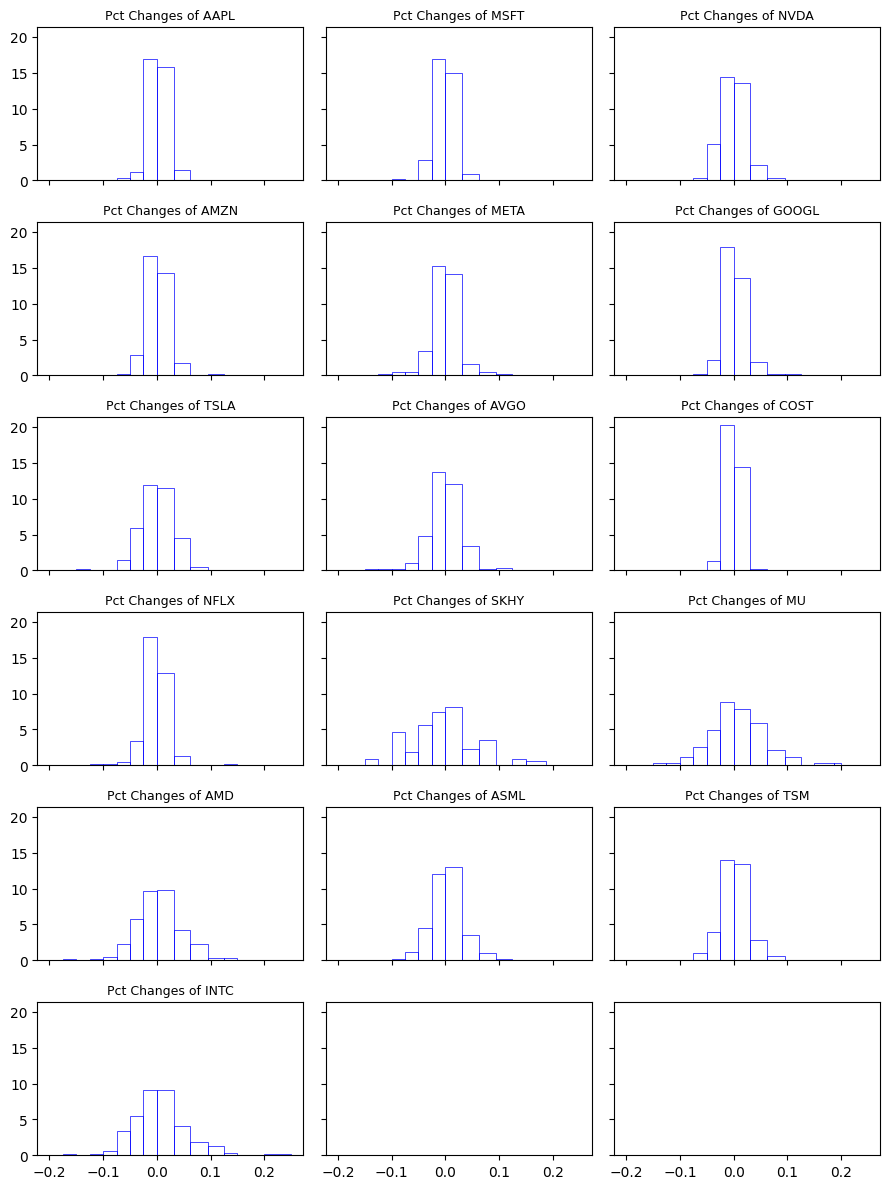

In [10]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
#yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
#yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))
b_class = [-0.2, -0.175, -0.15, -0.125, -0.1, -0.075, -0.05,-0.025, 0.0, 0.03125, 0.0625, 0.095, 0.125, 0.15, 0.1875, 0.2, 0.25]

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*3, sub_r*2),
                         sharex=True,
                         sharey=True
                         )
for ax, ticker in zip(axes.flat, tickers) :
  ax.hist(df_dat_cls[ticker].pct_change(fill_method=None), # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
          color='blue',
          linewidth=0.5,
          bins = b_class,       # 11처럼 갯수로 지정, 혹은 계급 구간 제시,
          facecolor='None',
          edgecolor='blue',
          density=True
          )
  ax.set_title(f" Pct Changes of {ticker} ", fontsize=9)
plt.tight_layout()
plt.show()

### two tickers, prices
뭔가 간단하게

In [5]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc_1= df_dat_cls['NFLX']
stck_prc_2 = df_dat_cls['GOOGL']


### two tickers, series plots
daily prices

#### daily pct changes in prices

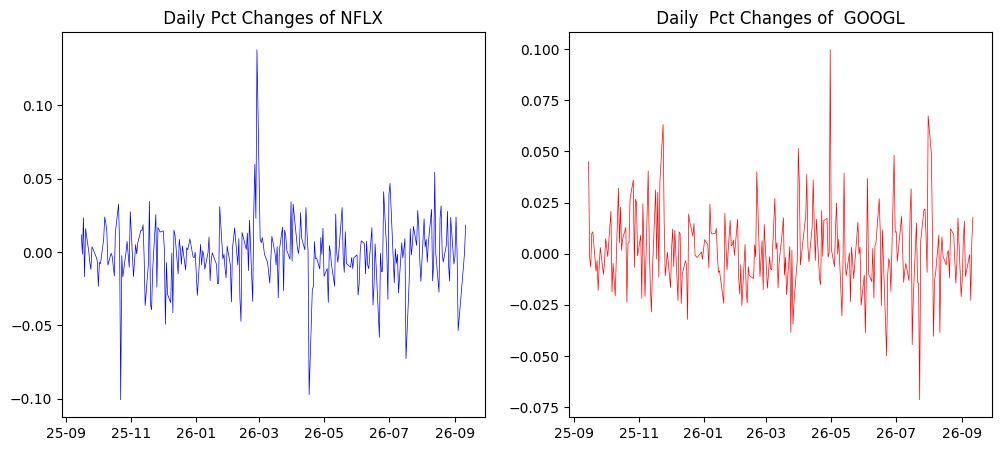

In [6]:
# 나란히 차트 2개. 1행, 2열.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharex=True)
axes[0].plot(yymmdd, stck_prc_1.pct_change(fill_method=None), color='blue', linewidth=0.5)
axes[1].plot(yymmdd, stck_prc_2.pct_change(fill_method=None), color='red', linewidth=0.5)

axes[0].set_title(f" Daily Pct Changes of NFLX ")
axes[1].set_title(f" Daily  Pct Changes of  GOOGL ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))


#### distibutions in one

(array([ 0.25739548,  0.77218645,  2.57395485, 13.89935619, 23.9377801 ,
        15.4437291 ,  4.63311873,  2.05916388,  0.51479097,  0.        ,
         0.25739548]),
 array([-0.07132621, -0.05578592, -0.04024563, -0.02470534, -0.00916506,
         0.00637523,  0.02191552,  0.03745581,  0.0529961 ,  0.06853639,
         0.08407667,  0.09961696]),
 <BarContainer object of 11 artists>)

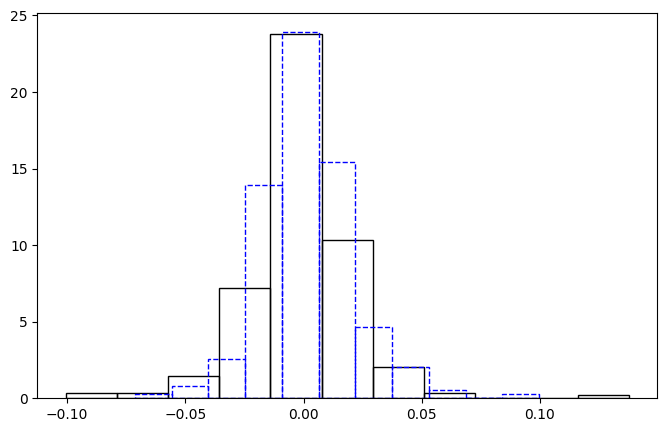

In [9]:
# 차트 여러 개, 화면 1개.
plt.figure(figsize=(8, 5))
plt.hist(stck_prc_1.pct_change(fill_method=None),
         color='blue',
         linewidth=1,
         bins = 11,
         facecolor='None',
         edgecolor='black',
         density=True
         )
plt.hist(stck_prc_2.pct_change(fill_method=None),
         color='blue',
         linewidth=1,
         bins = 11,
         facecolor='None',
         edgecolor='blue',
         density=True,
         linestyle='--'
         )
